# Étude du robot PUMA

*Par Erwan Maugeri, Charles-Antoine Maisonneuve*

- modèle géométrique / cinématique direct / inverse
    - Fixer les géométries du problème (longeur de bras, amplitude de pivot)
    - Déterminer l’ensemble des solutions (ici boule discontinue) “Workspace”
    - Associer position = tel mouvements (probablement plusieurs positions)
    - Dessiner les hodographe pour chaque commande (entrée : position, sortie : tracé de la trajectoire idéalement de chaque composante
- modèle dynamique/cinétique
    - ajouter la masse (permet de passer aux étapes suivantes)
    - bilan des efforts
- commande


## Fixer les dimensions du problème

mettre biblio \
terminer explications \
ajouter plan de route et décomposition du projet

Anatomie du PUMA:
- 2 parties: bras et tête
- que des lisaisons pivots
- 3 liaisons par partie (donc 6 au total)

<img src="anatomie_PUMA.png" height="300">

On note $R_0$ le socle puis $S_1, S_2, S_3$ les 3 parties du bras et la tête, que l'on étudiera pas tout de suite, et qu'on appelera parfois "outil".

<img src="schema_chaine_PUMA.png" height="300">

On définit ensuite les vecteurs $X_i \ Y_i \ Z_i$ de la base $R_i$ et les $q_i$ tel que
- $q _1 = (X_0, X_1)$
- $q _2 = (X_1, X_2)$
- $q _3 = (X_2, X_3)$

<img src="schema_PUMA.jpg" height="300">

On pose $L_0, L_1, L_2, L_3$ pour les longeurs de chaque bras

<img src="tailles.jpg" height="300">

## Préambule : Validation de la méthode et tests d'outils

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#### Quelques tests de graphes 3D (à ne pas inclure dans le rapport)

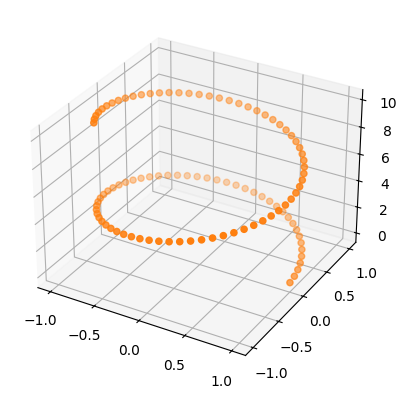

In [ ]:
# test d'une fonction paramétrique vu en cours

# Syntaxe des graphe 3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# ---


t = np.linspace(0,10,100)

x = np.cos(t)
y = np.sin(t)
z = t

ax.scatter(x, y, z, color="C1")

plt.show()

(array([[1, 2, 3],
       [1, 2, 3]]), array([[10, 10, 10],
       [20, 20, 20]]))
[[1 2 3]
 [1 2 3]]
[[10 10 10]
 [20 20 20]]
[[11 12 13]
 [21 22 23]]


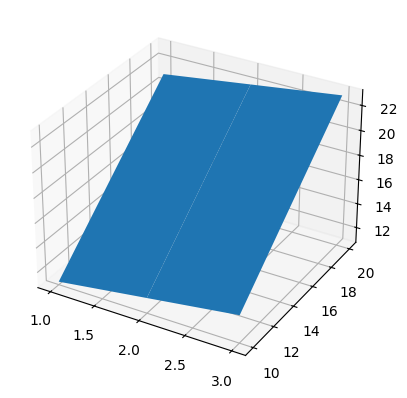

In [ ]:
# test meshgrid et plot_surface

x = np.array([1, 2, 3])
y = np.array([10, 20])

# mesgrid : couples (x,y) sous la forme de tableau (voir/tester syntaxe juste en dessous)

X = np.meshgrid(x, y)
# 2 tableaux 2*3 :
#
# ([x1,x2,x3], 
#  [x1,x2,x3])
#
# ([y1,y1,y1], 
#  [y2,y2,y2])

Y = np.meshgrid(y, x)
# 2 tableaux 3*2
#
# ([y1,y2], 
#  [y1,y2],
#  [y1,y2]) 
#
# ([x1,x1], 
#  [x2,x2],
#  [x3,x3])

print(X)

# L'une ou l'autre méthode n'a pas d'incidence sur Z(X,Y) MAIS il faut le même format entre X et Y

X,Y = np.meshgrid(x, y) # syntaxe associant directement les 2 matrices de combinaisons
# voir plutot: ligne à ligne (d'une matrice à l'autre) on a tous nos couples (x,y)
print(X)
print(Y)

Z = X + Y
print(Z)

# tracé de la surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

plt.show()

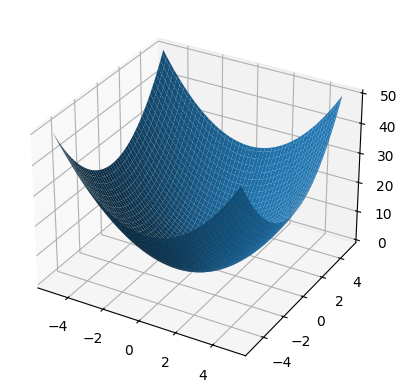

In [ ]:
# tests d'affichage de surfaces (paraboloïde)

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)  # Crée tous les couples (x,y) possibles

Z = X**2 + Y**2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z) # Associe pour un z les couples (x,y)

plt.show()

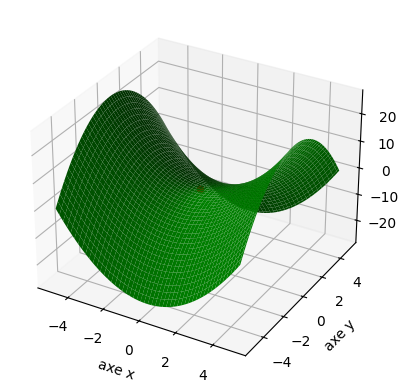

In [ ]:
# tests d'affichage de surfaces (point col)

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)  # Créer tous les couples (x,y) possibles

Z = X**2 - Y**2 # on def la fct z: (x,y) -> x^2 - y^2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, color="green")

# cherchons le point col
# dz/dx = 2*x = 0 si x = 0
# dz/dx = -2*y = 0 si y = 0
# donc (0,0, z=0^2-0^2=0) est le point col

ax.scatter(0,0,0, color='red')

# détails
ax.set_xlabel('axe x')
ax.set_ylabel('axe y')
ax.set_zlabel('axe z') # marche pas dans les fichiers notebook

plt.show()

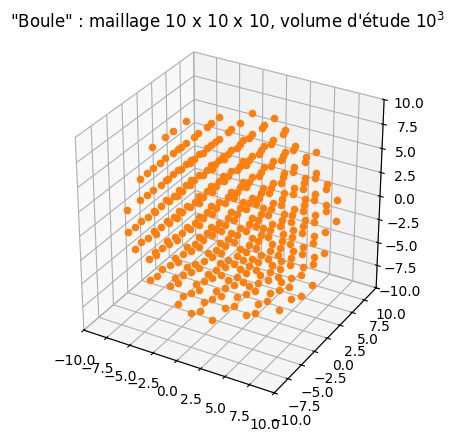

In [ ]:
# tracé d'une boule (pour le workspace) [triple itération, lent]

# paramètres
R = 10
Nx, Ny, Nz = 10, 10, 10 # maillage Nx * Ny * Nz

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

X = np.linspace(-R,R,Nx)
Y = np.linspace(-R,R,Ny)
Z = np.linspace(-R,R,Nz)

for x in X:
    for y in Y:
        for z in Z:
            if x**2 + y**2 + z**2 <= R**2:
                ax.scatter(x,y,z, color="C1")

ax.set_title(f"\"Boule\" : maillage {Nx} x {Ny} x {Nz}, volume d'étude {R}$^3$")

ax.set_xlim(-R,R)
ax.set_ylim(-R,R)
ax.set_zlim(-R,R)

ax.set_aspect('equal')
plt.show()

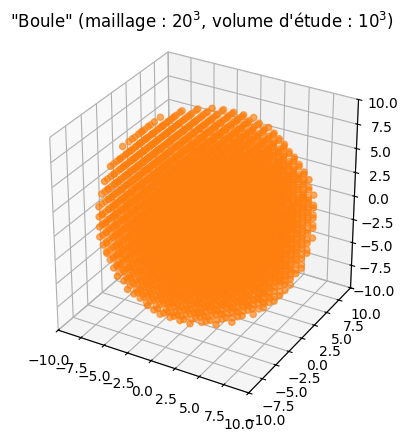

In [ ]:
# tracé d'une boule (pour le workspace) [avec meshgrid, rapide]

# paramètres
R = 10
N = 20 # maillage N**3 (résolution)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

t = np.linspace(-R,R,N)
X, Y, Z = np.meshgrid(t, t, t)

mask = ( X**2 + Y**2 + Z**2 <= R**2 ) # soit True soit False => 1 , 0
# print(mask)

ax.scatter(X[mask], Y[mask], Z[mask], color="C1")

ax.set_title(f"\"Boule\" (maillage : {N}$^3$, volume d'étude : {R}$^3$)")

ax.set_xlim(-R,R)
ax.set_ylim(-R,R)
ax.set_zlim(-R,R)

ax.set_aspect('equal')
plt.show()

#### modèle simple à 2 dimension: 2 bras de longeur L1 et L2

Initialisation

In [ ]:
# position cible
x = 3
y = 3

# Paramètres
L1 = 3
L2 = 1.5

# Limites articulaires
I_q1 = (-3/4*np.pi, 3/4*np.pi)
I_q2 = (-np.pi, np.pi)

In [ ]:
# modèles de géométrie inverse
def q1(x,y) :
    return np.arctan(y/x) - np.arccos( (L1**2 - L1**2 + x**2+ y**2) / (2*L1*np.sqrt(x**2 + y**2)) )

def q2(x,y) :
    return np.pi - np.arccos( (L1**2 + L2**2 - x**2 - y**2) / (2*L1*L2) )

Workspace et quelques tests

In [ ]:
def q(x,y):
    ''' Fonction qui prend une position x,y et renvoie les angles [q1,q2] ou "pas de solution" si le système ne peux pas atteindre (x,y) '''
    r = np.sqrt(x**2 + y**2)
    if abs(L1-L2) <= r <= L1+L2:
        q_1 = q1(x,y)
        q_2 = q2(x,y)
        if I_q1[0] <= q_1 <= I_q1[1] and I_q2[0] <= q_2 <= I_q2[1]:
            return [float(q_1), float(q_2)]
    else:
        print("pas de solution")
        return False

In [ ]:
x,y = 4,0
q(x,y)

[-0.8410686705679303, 1.0148141742743544]

ici on essaye de tracer le workspace mais on a plusieurs problèmes:
1. les fonctions qu'on utilise ne sont pas vectorisées donc on peut pas utiliser la méthode de "mask" qu'on a vu précédement
2. on divise parfois par 0 dans la fonction arctan

/var/folders/mt/fccg4c5d5zs03twxg91fh66h0000gn/T/ipykernel_2526/3833103936.py:3: RuntimeWarning: invalid value encountered in arccos
  return np.arctan(y/x) - np.arccos( (L1**2 - L1**2 + x**2+ y**2) / (2*L1*np.sqrt(x**2 + y**2)) )
/var/folders/mt/fccg4c5d5zs03twxg91fh66h0000gn/T/ipykernel_2526/3833103936.py:6: RuntimeWarning: invalid value encountered in arccos
  return np.pi - np.arccos( (L1**2 + L2**2 - x**2 - y**2) / (2*L1*L2) )


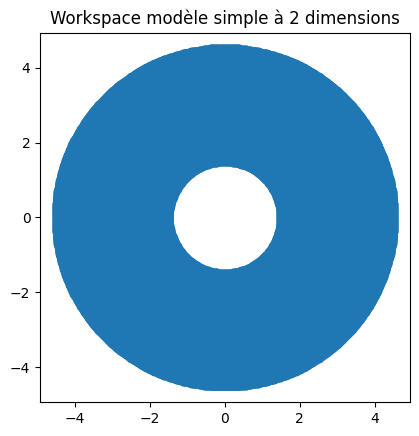

In [ ]:
# Workspace
# si |L1 - L2| ≤ r ≤ L1 + L2
# et si q1 ∈ I1 , q2 ∈ I2
# donc une portion de donut

N = 500
x = np.linspace(-(L1+L2), L1+L2, N)
y = np.linspace(-(L1+L2), L1+L2, N)

X,Y = np.meshgrid(x,y)
R = np.sqrt(X**2 + Y**2)

# c'est là que ma cinématique inverse intervient
Q1 = q1(X, Y)
Q2 = q2(X, Y)

mask = (np.abs(L1-L2) <= R) & (R <= L1+L2)

fig, ax = plt.subplots()

ax.scatter(X[mask], Y[mask])

ax.set_aspect('equal')
ax.set_title('Workspace modèle simple à 2 dimensions')
plt.show()

Donc j'ai demandé à chatGPT de perfectionner mes fonctions

In [ ]:
# modèles de géométrie inverse (vectorisés)

def q1(x, y):
    r = np.sqrt(x**2 + y**2)
    with np.errstate(divide='ignore', invalid='ignore'):
        angle = np.arctan2(y, x) - np.arccos((L1**2 - L2**2 + x**2 + y**2) / (2 * L1 * r))
    return angle

def q2(x, y):
    r_squared = x**2 + y**2
    with np.errstate(divide='ignore', invalid='ignore'):
        angle = np.pi - np.arccos((L1**2 + L2**2 - r_squared) / (2 * L1 * L2))
    return angle

In [ ]:
# Filtrage des positions
def q(x, y):
    '''Retourne un masque booléen des points (x,y) atteignables et dans les limites articulaires.'''
    r = np.sqrt(x**2 + y**2)
    reachable = (np.abs(L1 - L2) <= r) & (r <= L1 + L2)
    q1_vals = q1(x, y)
    q2_vals = q2(x, y)
    q1_valid = (I_q1[0] <= q1_vals) & (q1_vals <= I_q1[1])
    q2_valid = (I_q2[0] <= q2_vals) & (q2_vals <= I_q2[1])
    return reachable & q1_valid & q2_valid

In [ ]:
# petit test
x,y = 4,0

if q(x,y) == True :
    print(q1(x,y),q2(x,y))
else : print("pas de solution")

-0.32416610571643195 1.0148141742743544


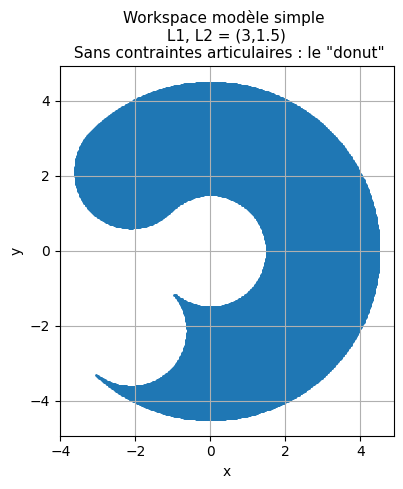

In [ ]:
# dessiner le workspace

N = 500
x = np.linspace(-(L1 + L2), L1 + L2, N)
y = np.linspace(-(L1 + L2), L1 + L2, N)
X, Y = np.meshgrid(x, y)

mask = q(X, Y)

fig, ax = plt.subplots()
ax.scatter(X[mask], Y[mask], s=1)

ax.set_aspect('equal')
plt.grid(True)

ax.set_title(f'Workspace modèle simple \n L1, L2 = ({L1},{L2}) \n Sans contraintes articulaires : le "donut"' , size='11')
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.show()

\* Note pour la config $L_1, L_2$ = (3,3) et ($q_1$ , $q_2$) ∈ [-2.36 ; 2.36] x [-3.14 ; 3.14] : <br>
Il manque quand même le contour lorsque $q_1 = - \pi$ et qu'on fait tourner $L_2$ autour de son pivot. Ci-dessous ce à quoi ça devrait ressembler. Mais bon ... c'est déjà une très bonne approximation.

<img src="workspace2d_correct.png" height="300">

### Fonction arctan et atan2

$\arctan(u)$ -> angle $\in [-\frac\pi2 ; \frac\pi2] $ , u généralement un ratio $\frac xy$
Problèmes pour la robotique:
* La perte du quadrant : Mathématiquement, $\frac{-y}{-x}$ est égal à $\frac{y}{x}$. La fonction classique $\arctan$ est incapable de faire la différence entre un point situé en bas à gauche $(-x, -y)$ et un point situé en haut à droite $(x, y)$
* La division par zéro : Si un point se trouve pile sur l'axe vertical ($x = 0$), le calcul $\frac{y}{0}$ provoque une erreur mathématique

La fonction $\text{atan2}(y, x)$ résout cela. Au lieu de prendre un ratio, elle prend les deux coordonnées séparément.
*	Elle regarde le signe de $x$ et de $y$ pour savoir exactement dans lequel des 4 quadrants se trouve le point.
*	Elle renvoie un angle sur un cercle complet, soit entre $-\pi$ et $\pi$ (-180° et 180°).
*	Si $x = 0$, elle ne plante pas et renvoie simplement $\frac{\pi}{2}$ (si $y > 0$) ou $-\frac{\pi}{2}$ (si $y < 0$).

## Étude du bras

In [ ]:
# Valeurs types PUMA 560 (en m)
d1 = 0.0660
d2 = 0.0149
a2 = 0.0432
d3 = 0
a4 = 0.0433

# Limites articulaires
I_q1 = (-160, 160)
I_q2 = (-225, 45)
I_q3 = (-225, 45)

### Géométrie Directe

$$\overrightarrow{OA} = \begin{pmatrix} 0 \\ 0 \\ L_0 \end{pmatrix}_{R_0}$$


$$\overrightarrow{OB} = \begin{pmatrix} -L_1 sin(q_1) \\ L_1 cos(q_1) \\ L_0 \end{pmatrix}_{R_0}$$

$$\overrightarrow{BC} = \begin{pmatrix} L_2 cos(q_2) \\ 0 \\ L_2 sin(q_2) \end{pmatrix}_{R_1} 
= L_2 cos(q_2) [\ cos(q_1)\overrightarrow{X_0} + sin(q_1)\overrightarrow{Y_0}\ ] + L_2 sin(q_2) \overrightarrow{Z_0} $$

$$= \begin{pmatrix} L_2 cos(q_2) cos(q_1) \\ L_2 cos(q_2) sin(q_1) \\ L_2 sin(q_2) \end{pmatrix}_{R_0}$$

Donc : $$\overrightarrow{OC} = \begin{pmatrix} -L_1 sin(q_1) + L_2 cos(q_2) cos(q_1) \\ L_1 cos(q_1) + L_2 cos(q_2) sin(q_1) \\ L_0 + L_2 sin(q_2) \end{pmatrix}_{R_0}$$


$$\overrightarrow{CD} = \begin{pmatrix} -L_3 sin(q_3) \\ L_3 cos(q_3) \\ 0 \end{pmatrix}_{R_2}$$

Or : \
$\overrightarrow{X_2} = cos(q_2)\overrightarrow{X_1} + sin(q_2)\overrightarrow{Z_1}$ \
$\overrightarrow{Y_2} = cos(q_2)\overrightarrow{Z_1} - sin(q_2)\overrightarrow{X_1}$

Donc:

$$\overrightarrow{CD} = -L_3 sin(q_3) [\ cos(q_2)\overrightarrow{X_1} + sin(q_2)\overrightarrow{Z_1}\ ] + L_3 cos(q_3) [\ cos(q_2)\overrightarrow{Z_1} - sin(q_2)\overrightarrow{X_1}\ ]$$

$$= \begin{pmatrix} -L_3 [\ sin(q_3) cos(q_2) + cos(q_3) sin(q_2)\ ] \\ 0 \\ L_3 [\ -sin(q_3) sin(q_2) + cos(q_3) cos(q_2)\ ] \end{pmatrix}_{R_1}
= \begin{pmatrix} -L_3 sin(q_2 + q_3) \\ 0 \\ L_3 cos(q_2 + q_3) \end{pmatrix}_{R_1}$$

$$= -L_3 sin(q_3 + q_2) [\ cos(q_1)\overrightarrow{X_0} + sin(q_1)\overrightarrow{Y_0}\ ] + L_3 cos(q_3 + q_2)\overrightarrow{Z_0}$$

$$\overrightarrow{CD} = \begin{pmatrix} -L_3 sin(q_2 + q_3) cos(q_1) \\ -L_3 sin(q_2 + q_3) sin(q_1) \\ L_3 cos(q_3 + q_2) \end{pmatrix}_{R_0}$$

$$\overrightarrow{OD} = \overrightarrow{OC} + \overrightarrow{CD} = \begin{pmatrix} -L_3 sin(q_2 + q_3) cos(q_1) - L_1 sin(q_1) + L_2 cos(q_1) cos(q_2) \\ -L_3 sin(q_2 + q_3) sin(q_1) + L_1 cos(q_1) + L_2 cos(q_2) sin(q_1) \\ L_0 + L_2 sin(q_2) + L_3 cos(q_2 + q_3) \end{pmatrix}_{R_0}$$

In [ ]:
def OA():
    return np.array([0.0, 0.0, d1])

def OB(q1):
    q1 = np.atleast_1d(q1)
    x = -d2 * np.sin(q1)
    y = d2 * np.cos(q1)
    z = np.full_like(q1, d1)
    return np.vstack((x, y, z)).squeeze()

def OC(q1, q2):
    q1 = np.atleast_1d(q1)
    q2 = np.atleast_1d(q2)
    x = -d2 * np.sin(q1) + a2 * np.cos(q2) * np.cos(q1)
    y = d2 * np.cos(q1) + a2 * np.cos(q2) * np.sin(q1)
    z = d1 + a2 * np.sin(q2)
    z = np.broadcast_to(z, q1.shape)
    return np.vstack((x, y, z)).squeeze()

def OD(q1, q2, q3):
    q1 = np.atleast_1d(q1)
    q2 = np.atleast_1d(q2)
    q3 = np.atleast_1d(q3)
    x = -a4 * np.sin(q2 + q3) * np.cos(q1) - d2 * np.sin(q1) + a2 * np.cos(q2) * np.cos(q1)
    y = -a4 * np.sin(q2 + q3) * np.sin(q1) + d2 * np.cos(q1) + a2 * np.cos(q2) * np.sin(q1)
    z = d1 + a2 * np.sin(q2) + a4 * np.cos(q3 + q2)
    z = np.broadcast_to(z, q1.shape)
    return np.vstack((x, y, z)).squeeze()

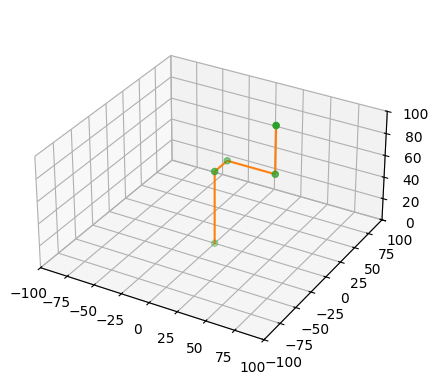

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

q1=.0
q2=0
q3=0

A = OA()
B = OB(q1)
C = OC(q1, q2)
D = OD(q1, q2, q3)

X = [0,A[0], B[0], C[0], D[0]]
Y = [0,A[1], B[1], C[1], D[1]]
Z = [0,A[2], B[2], C[2], D[2]]

ax.plot(X, Y, Z, color="C1")
ax.scatter(X, Y, Z, color="C2")

R=100
ax.set_xlim(-R,R)
ax.set_ylim(-R,R)
ax.set_zlim(0,R)
ax.set_aspect('equal')

plt.show()

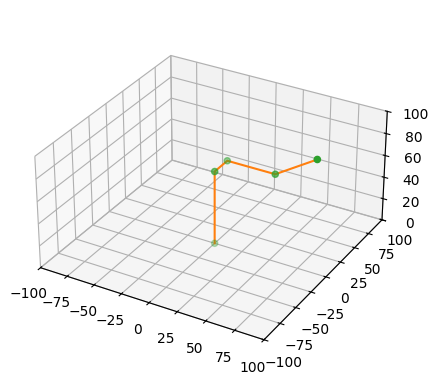

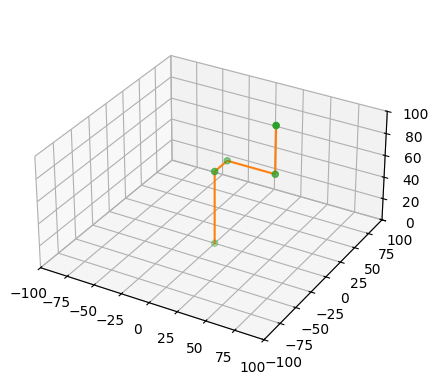

In [ ]:
for q3 in range(-1, 1):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    q1=0
    q2=0

    A = OA()
    B = OB(q1)
    C = OC(q1, q2)
    D = OD(q1, q2, q3)

    X = [0,A[0], B[0], C[0], D[0]]
    Y = [0,A[1], B[1], C[1], D[1]]
    Z = [0,A[2], B[2], C[2], D[2]]

    ax.plot(X, Y, Z, color="C1")
    ax.scatter(X, Y, Z, color="C2")

    R=100
    ax.set_xlim(-R,R)
    ax.set_ylim(-R,R)
    ax.set_zlim(0,R)
    ax.set_aspect('equal')

    # plt.savefig(f"animation1/position_bras{q3+3}.png", dpi=300, bbox_inches="tight")

### Passage en géométrie inverse

$$q_1 = \text{atan2}(y, x) - \text{atan2}\left(L_1, \pm \sqrt{x^2 + y^2 - L_1^2}\right)$$
$$q_2 = \text{atan2}(A Z - B R, A R + B Z)$$
$$q_3 = \text{atan2}\left(D, \pm \sqrt{1 - D^2}\right)$$

Variables intermédiaires:

$R = x \cos(q_1) + y \sin(q_1) \\
Z = z - L_0 \\
D = \frac{L_2^2 + L_3^2 - (R^2 + Z^2)}{2 L_2 L_3} \\
A = L_2 - L_3 \sin(q_3) \\
B = L_3 \cos(q_3)$

ici il faut expliquer la config bras droit/ bras gauche (1 ou -1)
* s1 = 1 : Configuration Bras Droit (Righty)
* s1 = -1 : Configuration Bras Gauche (Lefty) => le montrer dans les quadrants

les tests intermédiaires de workspace
1. Le test r_q1_sq < 0 (soit $x^2 + y^2 - L_1^2 < 0$)
*	Mathématiquement : On calcule une racine carrée $\sqrt{x^2 + y^2 - L_1^2}$. Pour que le résultat soit un nombre réel, la valeur sous la racine doit être positive ou nulle. Il faut donc que $x^2 + y^2 \ge L_1^2$.
*	Physiquement : $x^2 + y^2$ est le carré de la distance de la cible par rapport à l'axe Z (l'axe de la base). $L_1$ est le décalage de l'épaule. Cela signifie qu'il existe un "cylindre" de rayon $L_1$ autour de l'axe central dans lequel le robot ne peut physiquement pas rentrer son outil, car son épaule l'en empêche.
2. Le test abs(D) > 1 (soit $|D| > 1$)
*	Mathématiquement : En résolvant le système, nous avons posé l'égalité $\sin(q_3) = D$. Or, la fonction sinus est strictement bornée entre -1 et 1. Si les équations aboutissent à $D = 1.2$, l'équation $\sin(q_3) = 1.2$ n'a aucune solution réelle.
*	Physiquement : Cela découle du théorème d'Al-Kashi (loi des cosinus) sur le triangle formé par l'arrière-bras ($L_2$), l'avant-bras ($L_3$) et la distance entre l'épaule et le poignet ($\sqrt{R^2 + Z^2}$). Ce test vérifie l'inégalité triangulaire : la cible ne doit pas être trop loin (le bras ne peut pas s'étirer au-delà de $L_2 + L_3$) ni trop près (les segments ne peuvent pas se replier au-delà de $|L_2 - L_3|$).

In [ ]:
def q(x, y, z, s1=1, s3=1):
    """ Calcule le modèle géometrique inverse: possition (x,y,z) -> angles (q1,q2,q3)
    
    s1 et s2 permettent de choisir la configuration articulaire : config bras droit, bras gauche. 
    s1 et s3 doivent valoir 1 ou -1. Pré-remplis sur 1 (config Righty)"""

    r_q1_sq = x**2 + y**2 - d2**2
    if r_q1_sq < 0:
        print("Erreur : x, y hors de portée")
        return False
        
    q1 = np.arctan2(y, x) - np.arctan2(d2, s1 * np.sqrt(r_q1_sq))
    
    R = x * np.cos(q1) + y * np.sin(q1)
    Z = z - d1
    
    D = (a2**2 + a4**2 - (R**2 + Z**2)) / (2 * a2 * a4)
    
    if abs(D) > 1:
        print("Erreur : Distance hors de portée")
        return False
        
    q3 = np.arctan2(D, s3 * np.sqrt(1 - D**2))
    
    A = a2 - a4 * np.sin(q3)
    B = a4 * np.cos(q3)
    
    q2 = np.arctan2(A * Z - B * R, A * R + B * Z)
    
    if not (np.deg2rad(I_q1[0]) <= q1 <= np.deg2rad(I_q1[1])) or \
       not (np.deg2rad(I_q2[0]) <= q2 <= np.deg2rad(I_q2[1])) or \
       not (np.deg2rad(I_q3[0]) <= q3 <= np.deg2rad(I_q3[1])):
        print("Erreur : Limites articulaires dépassées")
        return False
        
    return q1, q2, q3

In [ ]:
# test qui marche
print(q(0.05, 0.015, 0.066, s1=1, s3=1))
# test qui ne marche pas
print(q(0, 0, 0, s1=1, s3=1))

(np.float64(-0.1017262535192685), np.float64(-0.9787242005299249), np.float64(0.38665207426495324))
Erreur : x, y hors de portée
False


### Workspace (expérimentation d'une méthode réelle)

première méthode (force brute)

explications uniquement, sur la base de ce qu'on a fait en 2D

méthode : échantillonage puis définition d'un coeff d'erreur
utilité: Pour faciliter les calculs lorsque l’IK exacte est compliquée (il y a plusieurs solutions, le robot a beaucoup de ddl) et que l'on veut une réponse très rapide.

déterminer $\epsilon$ : objetifs et cohérence

faire l'aquisition des points

In [ ]:
# aquisition des points



### Géométrie Directe avec matrices Denavit-Hartenberg (DH)

**Ce que l'on a fait :**

Dessiner les repères $R_0, R_1, R_2, R_3$ de manière intuitive, puis projeter manuellement les vecteurs les uns sur les autres (par exemple, exprimer $\overrightarrow{CD}$ du repère $R_2$ vers $R_1$, puis vers $R_0$). 

* **Avantage** : est que l'on comprend parfaitement la physique et la géométrie du bras en le faisant. 
* **Inconvénient** : Il est très facile de faire une erreur de signe ($\pm \sin$ ou $\pm \cos$) lors des projections à la main sur papier.


**Ce que fait Denavit-Hartenberg (La méthode algorithmique) :**

La méthode DH impose des règles ultra-strictes pour placer les repères (par exemple : l'axe $\overrightarrow{X_i}$ doit obligatoirement être perpendiculaire à $\overrightarrow{Z_{i-1}}$ et $\overrightarrow{Z_i}$).
Une fois ces repères placés selon la règle, on n'a plus besoin de réfléchir ou de projeter des forces/vecteurs sur un dessin. On a juste à :
1.	Remplir un tableau avec les 4 paramètres ($d_i, \theta_i, a_i, \alpha_i$) pour chaque segment.
2.	Remplacer ces valeurs dans la matrice générique.
3.	Laisser l'ordinateur multiplier les matrices entre elles.

Cette méthode sera aussi très utilse pour passer à l'analyse cinématique **directe** puis à la géométrie et cinématique **inverse**.

**Placement des axes**

Pour définir une transformation entre deux repères, il faut 6 paramètres (3 rotations, 3 translations). La méthode de Denavit Hartenberg permet de définir la transformation grâce à quatre paramètres. Pour cela il faut définir les axes suivants certaines règles :
* l'axe $Z_i$ est porté par l'axe de la liaison reliant le corps $C_{i-1}$ au corps $C_i$
* l'axe $X_i$ est porté par la normale commune à $Z_{i-1}$ et $Z_i$ donc : $X_i = Z_{i-1} \wedge Z_i$
* l'axe $Y_i$ est choisi à ce que le repère soit direct : $Y_i = Z_i \wedge X_i$

**Paramètres géométriques**

La méthode Denavit-Hartenberg décompose le passage d'un repère ($i-1$) au suivant ($i$) en 4 mouvements élémentaires : 2 translations et 2 rotations. La particularité de la méthode de Denavit-Hartenberg (DH) est donc qu'elle exclut l'axe $Y$ du calcul. 

On positionne alors les repères de manière à ce que tous les déplacements se fassent uniquement selon les axes $X$ et $Z$ (l'axe $Y$ servant uniquement à fermer le repère [règle de la main droite] on ne le fait pas figurer sur le schéma).

Chaque liaison est ainsi définie par 4 paramètres
* $d_i$ : Translation selon $Z_{i-1}$
* $\theta_i$ : Rotation autour de $Z_{i-1}$ (angle entre $X_{i-1}$ et $X_i$)
* $a_i$ : Translation selon $X_i$
* $\alpha_i$ : Rotation autour de $X_i$ (angle entre $Z_{i-1}$ et $Z_i$)

Le schéma suivant résume toutes les règles précédentes

<img src="DH.png" height="300">

**Adaptation du modèle précédent et construction des matrices**

On change alors légèrement la paramétrisation "naturelle" que l'on avait choisit précédement. (décrire les changements)

<img src="schema_PUMA_normeDH.png" height="300">

On construit alors le tableau suivant:

| | $i$ |$d_i$ (décalage selon z)|$\theta_i$ (rotation autour de z)|$a_i$ (décalage selon x)|$\alpha_i$ (rotation autour de x)|
|---------------|---|-----------|-----------|-----------|-----------|
| ${}^{0}T^{1}$ | $1$ | $d_1$     | $q_1$     | 0         | -90°      |
| ${}^{1}T^{2}$ | $2$ | $d_2$     | $q_2$     | $a_2$     | 0         |
| ${}^{2}T^{3}$ | $3$ | $-d_3$     | $q_3$     | $a_4$        | 0       |

Et on écris les matrices ${}^{i-1}T^{i}$ en suivant le modèle suivant (dont on ne fera pas la démonstration ici):

$$ {}^{i-1}T^{i} =
\begin{bmatrix}
\cos \theta_i & -\cos \alpha_i \sin \theta_i & \sin \alpha_i \sin \theta_i & a_i \cos \theta_i \\
\sin \theta_i & \cos \alpha_i \cos \theta_i & -\sin \alpha_i \cos \theta_i & a_i \sin \theta_i \\
0 & \sin \alpha_i & \cos \alpha_i & d_i \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

**Fonctionnement de chaine**

Ces matrices fonctionnent en chaine. Admettons je veuille connaitre la position du bras 3: 
$${}^{0}T^{3}(q_1, q_2, q_3) = {}^{0}T^{1}(q_1) \times {}^{1}T^{2}(q_2) \times {}^{2}T^{3}(q_3)$$

On donne ${}^{0}T^{1}$, ${}^{1}T^{2}$ et ${}^{2}T^{3}$ ci-dessous:

In [ ]:
def T_i(di, theta_i, ai, alpha_i):
    # représente T de i-1 vers i
    return np.array([
        [np.cos(theta_i), -np.cos(alpha_i)*np.sin(theta_i),  np.sin(alpha_i)*np.sin(theta_i), ai*np.cos(theta_i)],
        [np.sin(theta_i),  np.cos(alpha_i)*np.cos(theta_i), -np.sin(alpha_i)*np.cos(theta_i), ai*np.sin(theta_i)],
        [0, np.sin(alpha_i), np.cos(alpha_i), di],
        [0, 0, 0, 1]
    ])

## Problème complet en cinématique

tâches:
* rediger matrices DH pour chaque articulation
* calculer la jacobienne
* faire du suivi de trajectoire
* trouver des matrices dynamiques et décrire dans les grandes lignes le suivi 1 (en ouverture)

interprétations \
-> changer le K selon la situation \
-> evaluer son efficacité

## Suivi de trajectoires

v en cm/s [-7.5  2.4  8. ]
detJ -319999.9999999998
80.0 3.061616997868383e-15 150.0
ERREUR = [ -5.  25. -20.]
VITESSE = [ -500.  2500. -2000.]
dq = [ 31.25 -25.    35.  ]
69.00896642598366 22.29584778916676 129.95789152353947
ERREUR = [ 5.99103357 22.70415221  0.04210848]
VITESSE = [ 599.1033574  2270.41522108    4.21084765]
dq = [ 27.25083917  -1.62886635 -24.50850512]
71.04358529886231 47.055739835530744 128.29815632412465
ERREUR = [ 4.35638804 -2.0597397   1.70184368]
VITESSE = [ 435.6388035  -205.97397022  170.18436759]
dq = [-4.83822302  2.61505725 -6.55428611]
75.3516162083594 44.823116097152074 129.96876487520592
ERREUR = [0.44817048 0.16088604 0.03123512]
VITESSE = [44.81704754 16.08860361  3.12351248]
dq = [-0.10362167  0.15489738 -1.0487593 ]
75.79956588219916 44.98330783627291 129.99806662581722
ERREUR = [ 0.39971425 -0.01929704  0.00193337]
VITESSE = [39.97142474 -1.92970376  0.19333742]
dq = [-0.25026381  0.0892846  -0.73751062]
76.19925125686706 44.963022985674975 129.998

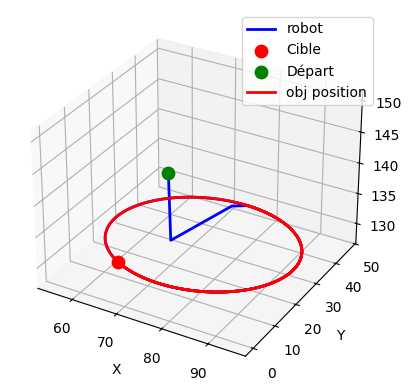

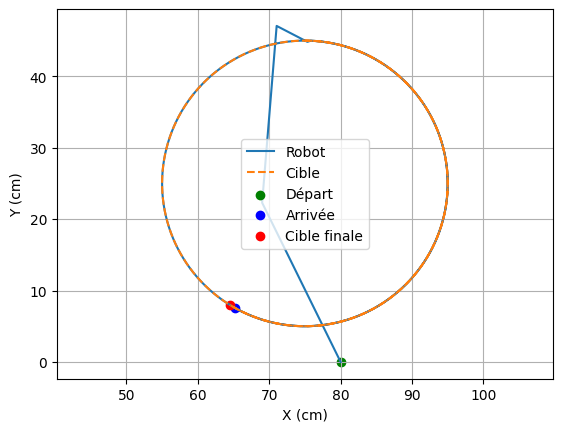

[array([ -5.,  25., -20.]), array([ 5.99103357, 22.70415221,  0.04210848]), array([ 4.35638804, -2.0597397 ,  1.70184368]), array([0.44817048, 0.16088604, 0.03123512]), array([ 0.39971425, -0.01929704,  0.00193337]), array([ 0.39904262, -0.02698886,  0.00101948]), array([ 0.39841471, -0.03494933,  0.00099533]), array([ 0.39762825, -0.04289474,  0.00096977]), array([ 0.39668305, -0.05082379,  0.00094417]), array([ 0.39557948, -0.05873332,  0.00091854]), array([ 0.39431795, -0.06662013,  0.0008929 ]), array([ 0.39289895, -0.07448109,  0.00086727]), array([ 0.39132303, -0.08231302,  0.00084168]), array([ 0.3895908 , -0.0901128 ,  0.00081614]), array([ 0.38770294, -0.09787729,  0.00079069]), array([ 0.38566018, -0.10560337,  0.00076533]), array([ 0.38346333, -0.11328794,  0.0007401 ]), array([ 0.38111325, -0.12092792,  0.000715  ]), array([ 0.37861087, -0.12852023,  0.00069006]), array([ 0.37595717, -0.13606183,  0.0006653 ]), array([ 0.37315321, -0.14354968,  0.00064074]), array([ 0.37020

In [ ]:
# programme de ChAn
import numpy as np

d1 = 100 #buste
d2 = 80 #bras
d3 = 50 #avant-bras

def DH(theta, d, a, alpha):
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct, -st*ca,  st*sa, a*ct],
        [st,  ct*ca, -ct*sa, a*st],
        [ 0,     sa,     ca,    d],
        [ 0,      0,      0,    1]
    ])

def MGD(q1, q2, q3):
    T01 = DH(q1,d1,0,np.pi/2)
    T12 = DH(q2,0, d2,  0)
    T23 = DH(q3,0,d3,0)

    T03 = T01 @ T12 @ T23
    return T03[:3, 3]


q1 = np.deg2rad(0)
q2 = np.deg2rad(0)
q3 = np.deg2rad(90)

p=MGD(q1,q2,q3)

#print(p)

#MCD

def J(q1, q2, q3):


    r = d2*np.cos(q2) + d3*np.cos(q2+q3)


    J = np.array([
        [-r*np.sin(q1),
         (-d2*np.sin(q2) - d3*np.sin(q2+q3))*np.cos(q1),
         -d3*np.sin(q2+q3)*np.cos(q1)],


        [r*np.cos(q1),
         (-d2*np.sin(q2) - d3*np.sin(q2+q3))*np.sin(q1),
         -d3*np.sin(q2+q3)*np.sin(q1)],


        [0,
         d2*np.cos(q2) + d3*np.cos(q2+q3),
         d3*np.cos(q2+q3)]
    ])

    return J

#vitesse angulaire en rad/s
dq1=0.03
dq2=0.1
dq3=0.05

dq= [dq1,dq2,dq3]

v=J(q1,q2,q3) @ dq
print("v en cm/s",v)

#vérification des position ou le robot perd degré de liberté
#quand le robot perd une direction de ouvement indépendante
detJ = np.linalg.det(J(q1,q2,q3))
print("detJ",detJ)


#liste de stockage de la trajecoitee
traj_x=[]
traj_y=[]
traj_z=[]

#stockage de la trajectoire du point cible

traj_x_cible=[]
traj_y_cible=[]
traj_z_cible=[]

stock_e=[]

#boucle mouvement continue




#position de départ du point de trajectoire
x_cible = 75
y_cible = 25
z_cible = 130


dist = np.sqrt(x_cible**2 + y_cible**2 + (z_cible - d1)**2)


K = 100  # gain


dt=0.01
t=0


R=d1+d2+d3


distance=0


epsilon=0.1


prev_x, prev_y, prev_z = None, None, None


if dist > R:
    raise SystemExit(" Position impossible")
else:
    for i in range(500):
        x,y,z=MGD(q1,q2,q3) #position actuelle
        print(x,y,z)
       
        #écrat entre postion souhaité et postion actuelle
        e = np.array([x_cible - x,y_cible - y,z_cible - z])


        print("ERREUR =", e)


        if np.linalg.norm(e) < epsilon:
            print("Position atteinte")
            break
        else:






            #vitesse outil
            v = K * e


            print("VITESSE =", v)




            Jmat = J(q1, q2, q3)


            dq = np.linalg.pinv(Jmat) @ v  #inverse de Jmat * v


            print("dq =", dq)
   
            #mise à jour des angles
            q1 +=dq[0]*dt
            q2 += dq[1]*dt
            q3 += dq[2]*dt




            t+=dt
            prev_x,prev_y,prev_z=x,y,z


            traj_x.append(x)
            traj_y.append(y)
            traj_z.append(z)
            stock_e.append(e)


            #rayon du cercle de la trajectoire de x,ycible
            M=20


            x_cible= 75+ M*np.sin(i*0.02)
            y_cible = 25+ M*np.cos(i*0.02)


            traj_x_cible.append(x_cible)
            traj_y_cible.append(y_cible)
            traj_z_cible.append(z_cible)










    #graphe 3d
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D


    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')


    #trajectoire du robot
    ax.plot(traj_x, traj_y, traj_z,color="blue",linewidth=2, label="robot")


    ax.scatter(x_cible, y_cible, z_cible, color='red', s=80, label="Cible")


    ax.scatter(traj_x[0], traj_y[0], traj_z[0], color='green', s=80, label="Départ")




    #trajectoire de la cible
    ax.plot(traj_x_cible,traj_y_cible,traj_z_cible,color="red",linewidth=2,label="obj position")






    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")


    ax.legend()
    ax.grid(True)
    plt.show()


    plt.figure()






    plt.plot(traj_x, traj_y, label="Robot")
    plt.plot(traj_x_cible, traj_y_cible, '--', label="Cible")


    plt.scatter(traj_x[0], traj_y[0], color='green', label="Départ")
    plt.scatter(traj_x[-1], traj_y[-1], color='blue', label="Arrivée")
    plt.scatter(x_cible, y_cible, color='red', label="Cible finale")


    plt.xlabel("X (cm)")
    plt.ylabel("Y (cm)")


    plt.axis('equal')    # garde les bonnes proportions
    plt.grid(True)
    plt.legend()


    plt.show()

print(stock_e)


In [ ]:
# paramètres
d1=100
d2=0
d3=0
a1=80
d4=50

In [ ]:
# modèle de géométrie directe

def MGD(q1, q2, q3):
    """Retourne (x,y,z)
    Angles en radians"""

    r = a1*np.cos(q2) + d4*np.cos(q2 + q3)
    x = r*np.cos(q1)
    y = r*np.sin(q1)
    z = d1 + a1*np.sin(q2) + d4*np.sin(q2 + q3)

    return x, y, z

# modèle de géométrie inverse 
# (le même que précédement mais sans les tests)

def MGI(x, y, z, s3=1):
    """Calcule le modèle géometrique inverse: possition (x,y,z) -> angles (q1,q2,q3).
    s3 = +1 ou -1 choisit la config bras gauche, bras droit"""

    R = np.sqrt(x**2 + y**2)
    Z = z - d1
    q1 = np.arctan2(y, x)
    c3 = (R**2 + Z**2 - a1**2 - d4**2) / (2*a1*d4)
    c3 = np.clip(c3, -1.0, 1.0)
    s3_val = s3 * np.sqrt(1 - c3**2)
    q3 = np.arctan2(s3_val, c3)
    q2 = np.arctan2(Z, R) - np.arctan2(d4*np.sin(q3), a1 + d4*np.cos(q3))
    
    return q1, q2, q3



# Jacobienne

def jacobienne(q1, q2, q3):
    """ Retourne J(q)
        Angles en radian """
    # variables intermédiaires
    r = a1*np.cos(q2) + d4*np.cos(q2 + q3)
    dr_dq2 = (-a1*np.sin(q2)-d4*np.sin(q2 + q3))
    dr_dq3 = (-d4*np.sin(q2 + q3))

    J = np.array([
        [-r*np.sin(q1)  ,  np.cos(q1)*dr_dq2                  ,  np.cos(q1)*dr_dq3],
        [r*np.cos(q1)   ,  np.sin(q1)*dr_dq2                  ,  np.sin(q1)*dr_dq3],
        [    0.0        ,  a1*np.cos(q2) + d4*np.cos(q2 + q3) ,  d4*np.cos(q2 + q3)]
    ])

    return J



# LA fonction ultime
# (pseudo-inverse amortie "Damped Least Squares")
# rédigée avec l'IA

def cinematique_inv(q1,q2,q3,  vx,vy,vz,  damping=0.05,qdot_max=np.inf) :
    """
    Cinématique inverse différentielle robuste.

    Paramètres

    ----------

    q1,q2,q3 : float

        Angles articulaires [rad]

    vx,vy,vz : float

        Vitesse cartésienne désirée

    damping : float

        Amortissement DLS (0.01 à 0.1 typiquement)

    qdot_max : float

        Saturation max des vitesses articulaires

        (np.inf pour désactiver)

    Retour

    ------

    qdot : ndarray(3,)

        [q1_dot, q2_dot, q3_dot]

    """

    J = jacobienne(q1, q2, q3)

    v = np.array([vx, vy, vz], dtype=float)

    # Damped Least Squares

    A = J @ J.T + (damping**2) * np.eye(3)

    qdot = J.T @ np.linalg.solve(A, v)

    # Saturation éventuelle

    max_abs = np.max(np.abs(qdot))

    if max_abs > qdot_max:

        qdot *= qdot_max / max_abs

    return qdot


test simple, point fixe à atteindre, aucune contrainte

-> penser à expliquer le dt en relation avec la précision

In [ ]:
# point de départ
x = 100
y = 0
z = 100

# point à atteindre
x_cible = 110
y_cible = 0
z_cible = 100

v_x = 10 # quelle unité ? m/s du coup
v_y =0
v_z = 0

dt = 0.01 # en sec

# géom. indirecte pour obtenir les q_i
q1, q2, q3 = MGI(x, y, z)


# cinematique inverse : passer de v à q point
qdot = cinematique_inv(q1,q2,q3,  v_x,v_y,v_z)


#nouveau point = q + dq avec dq = q_point * dt
q1 = q1 + qdot[0] * dt
q2 = q2 + qdot[1] * dt
q3 = q3 + qdot[2] * dt

# géométrie inverse pour (x,y,z)
x,y,z = MGD(q1,q2,q3)


print(f"x: {x:.2f} y: {y:.2f} z: {z:.2f}")

x: 100.10 y: 0.00 z: 100.00


trajectoire 1 : cercle

pour chaque position, calcul de   e = signe(v,tangente_traj) * | x_cible - x_puma |


trajectoire désirée ≠ mesurée

In [ ]:
# trajectoire détérministe -> je donne chemin + vitesse
# le cercle dans le plan x0y
def traj(t) :
    """ Définit la trajectoire
    Paramètre
    ----
    t : float, temps en secondes
    ----
    Sortie :    
    
    x,y,z : coordonnées en fct(t)
    ux, uy, uz : coordonnées du vecteur orienté
    """

    R = 100
    x,y,z = R*np.cos(t), R*np.sin(t), 100
    ux, uy, uz = -R*np.sin(t), R*np.cos(t), 0

    return x,y,z, ux, uy, uz

In [ ]:
# fonction trigo bizzare
def traj(t) :
    """ Définit la trajectoire
    Paramètre
    ----
    t : float, temps en secondes
    ----
    Sortie :    
    
    x,y,z : coordonnées en fct(t)
    ux, uy, uz : coordonnées du vecteur orienté
    """

    R = 50

    x = R*np.sin(2*t)
    y = R*np.cos(3*t)
    z = R*np.sin(5*t)

    ux = R*2*np.cos(2*t)
    uy = -R*3*np.sin(3*t)
    uz = R*5*np.cos(5*t)

    ux, uy, uz = -R*np.sin(t), R*np.cos(t), 0

    return x,y,z, ux, uy, uz

In [ ]:
# carré de côtés 100m dans le plan yOz
def traj(t) :
    """ Définit la trajectoire
    Paramètre 
    ----
    t : float, temps en secondes
    ----
    Sortie :    
    
    x,y,z : coordonnées en fct(t)
    ux, uy, uz : coordonnées du vecteur orienté
    """
    if t <= 1:
        x, y, z = 0, t*100, 0
        ux, uy, uz = 0, 100, 0
    elif t <= 2:
        x, y, z = 0, 100, (t-1)*100
        ux, uy, uz = 0, 0, 100
    elif t <= 3:
        x, y, z = 0, 100-(t-2)*100, 100
        ux, uy, uz = 0, -100, 0
    else:
        x, y, z = 0, 0, 100-(t-3)*100
        ux, uy, uz = 0, 0, -100

    return x,y,z, ux, uy, uz

In [ ]:
# PARAMETRES
N = 1000
T = 4
dt = T/(N-1)
K = 2

# vitesses max des articulations (rad/s)
Q1DOT_MAX = np.deg2rad(180)
Q2DOT_MAX = np.deg2rad(180)
Q3DOT_MAX = np.deg2rad(180)

# état initial du robot
x0 = 0
y0 = 0
z0 = 0
q1, q2, q3 = MGI(x0, y0, z0)

# STOCKAGE (initialisation)
temps = []
x_traj, y_traj, z_traj = [],[],[] # trajectoire cible
x_puma, y_puma, z_puma= [],[],[] # robot
q1_hist, q2_hist, q3_hist = [],[],[] # angles
erreur = [] # erreurs ||e|| distance
erreur_signee = [] # erreurs ||e|| distance * signe(angle obtu/aigu)
angle_aigu = [] # dépassement


for t in np.linspace(0, T, N):
    xt, yt, zt, ux, uy, uz = traj(t) # cible
    xp, yp, zp = MGD(q1, q2, q3) # robot

    # erreur

    e = np.array([xt - xp, yt - yp, zt - zp])
    norme_e = np.linalg.norm(e) # "distance"

    # vitesse cible

    v_traj = np.array([ux, uy, uz])

    # loi de commande

    v_cmd = v_traj + K*e

    # cinématique inverse
    
    qdot = cinematique_inv(
        q1,
        q2,
        q3,
        v_cmd[0],
        v_cmd[1],
        v_cmd[2]
    )

    # saturation moteurs (rédigé par IA)

    qdot[0] = np.clip(qdot[0], -Q1DOT_MAX, Q1DOT_MAX)
    qdot[1] = np.clip(qdot[1], -Q2DOT_MAX, Q2DOT_MAX)
    qdot[2] = np.clip(qdot[2], -Q3DOT_MAX, Q3DOT_MAX)

    # intégration (somme infinie)

    q1 += qdot[0]*dt
    q2 += qdot[1]*dt
    q3 += qdot[2]*dt

    # signe de l'erreur
    s = np.dot(v_traj, e)
    erreur_signee.append(np.sign(s)*norme_e)

    angle_aigu.append(s >= 0)

    # stockage
    
    temps.append(t)
    
    x_traj.append(xt)
    y_traj.append(yt)
    z_traj.append(zt)

    x_puma.append(xp)
    y_puma.append(yp)
    z_puma.append(zp)

    q1_hist.append(q1)
    q2_hist.append(q2)
    q3_hist.append(q3)

    erreur.append(norme_e)

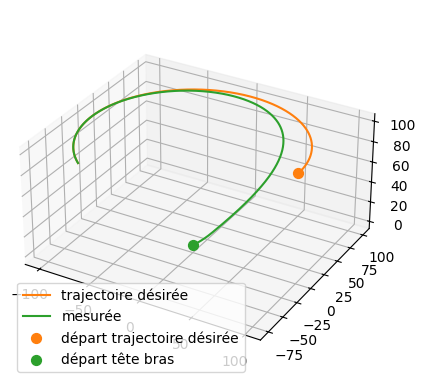

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# hodographes
ax.plot(x_traj, y_traj, z_traj, color="C1", label="trajectoire désirée")
ax.plot(x_puma, y_puma, z_puma, color="C2", label="mesurée")

ax.scatter(x_traj[0], y_traj[0], z_traj[0], color="C1", label="départ trajectoire désirée", s=50)
ax.scatter(x_puma[0], y_puma[0], z_puma[0], color="C2", label="départ tête bras",  s=50)

ax.set_aspect('equal')
R=100

plt.legend()
plt.show()

In [ ]:
#               ↙︎valeur de K
erreur_signee_10 = erreur_signee

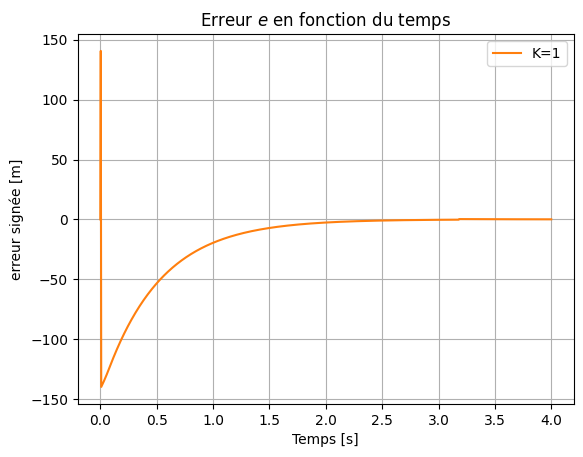

In [ ]:
t = np.linspace(0, T, N)
plt.plot(t, erreur_signee, label='K=1', color="C1")

plt.xlabel('Temps [s]')
plt.ylabel('erreur signée [m]')

plt.title('Erreur $e$ en fonction du temps')
plt.grid(True)
plt.legend()
plt.show()